<a href="https://colab.research.google.com/github/danokoth2001/danokoth2001/blob/main/LSTM_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Downloading stock exchange dor microsoft corporation

In [2]:
stock_frame = yf.download("MSFT", start="2021-01-01", end="2026-01-01")

/tmp/ipykernel_18635/3273562355.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_frame = yf.download("MSFT", start="2021-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Extracting only closing values

In [3]:
price_stream = stock_frame["Close"].values.reshape(-1, 1)

Normalize clossing patterns

In [4]:
scale_machine = MinMaxScaler(feature_range=(0,1))
price_scaled = scale_machine.fit_transform(price_stream)

creating time sequence

In [5]:
window_size = 12
feature_box = []
label_box = []

for j in range(window_size, len(price_scaled)-1):
    feature_box.append(price_scaled[j-window_size:j])

    if price_scaled[j+1] > price_scaled[j]:
        label_box.append(1)
    else:
        label_box.append(0)

feature_box = np.array(feature_box)
label_box = np.array(label_box)

splitting the dataset

In [6]:
full_size = len(feature_box)

cut1 = int(full_size * 0.70)
cut2 = int(full_size * 0.85)

x_train_set = feature_box[:cut1]
y_train_set = label_box[:cut1]

x_valid_set = feature_box[cut1:cut2]
y_valid_set = label_box[cut1:cut2]

x_exam_set = feature_box[cut2:]
y_exam_set = label_box[cut2:]

building LSTM model

In [7]:
trend_net = Sequential()

trend_net.add(LSTM(64, return_sequences=True, input_shape=(window_size,1)))
trend_net.add(Dropout(0.25))

trend_net.add(LSTM(24))
trend_net.add(Dropout(0.30))

trend_net.add(Dense(16, activation='relu'))
trend_net.add(Dense(1, activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


compile model

In [8]:
trend_net.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


train model

In [9]:
history_log = trend_net.fit(
    x_train_set,
    y_train_set,
    epochs=14,
    batch_size=16,
    validation_data=(x_valid_set, y_valid_set)
)


Epoch 1/14
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.5029 - loss: 0.6938 - val_accuracy: 0.5161 - val_loss: 0.6934
Epoch 2/14
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5052 - loss: 0.6928 - val_accuracy: 0.5161 - val_loss: 0.6947
Epoch 3/14
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5201 - loss: 0.6929 - val_accuracy: 0.5161 - val_loss: 0.6932
Epoch 4/14
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4960 - loss: 0.6943 - val_accuracy: 0.5161 - val_loss: 0.6933
Epoch 5/14
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5052 - loss: 0.6931 - val_accuracy: 0.5161 - val_loss: 0.6935
Epoch 6/14
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4626 - loss: 0.6943 - val_accuracy: 0.5161 - val_loss: 0.6948
Epoch 7/14
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5086 - loss: 0.6929 - val_accuracy: 0.5161 - val_loss: 0.6942
Epoch 8/14
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5190 - loss: 0.6923 - val_accuracy: 0.5161 - v

test accuracy evaluation

In [10]:
loss_score, accuracy_score_lstm = trend_net.evaluate(x_exam_set, y_exam_set)

print("LSTM Test Accuracy:", accuracy_score_lstm)
print("LSTM Test Loss:", loss_score)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5561 - loss: 0.6884 
LSTM Test Accuracy: 0.5561497211456299
LSTM Test Loss: 0.6883836388587952


trends prediction

In [11]:
future_guess = trend_net.predict(x_exam_set)
trend_labels = (future_guess > 0.5).astype(int)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step


confusion matrix

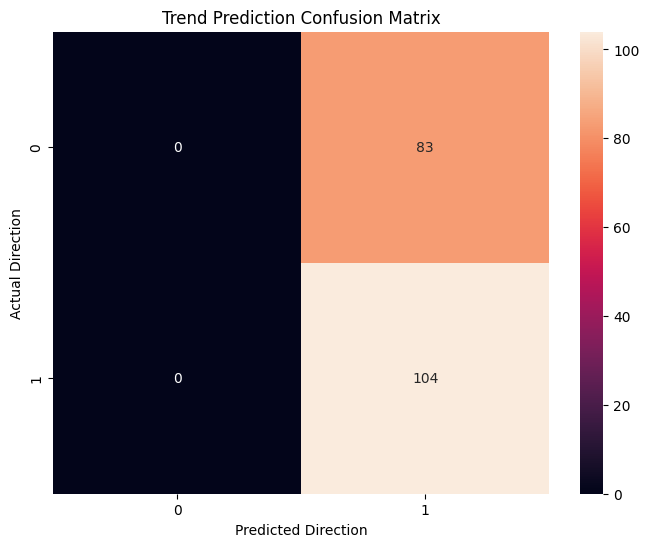

In [12]:
box_matrix = confusion_matrix(y_exam_set, trend_labels)

plt.figure(figsize=(8,6))
sns.heatmap(box_matrix, annot=True, fmt='d')
plt.title("Trend Prediction Confusion Matrix")
plt.xlabel("Predicted Direction")
plt.ylabel("Actual Direction")
plt.show()

classification report

In [13]:
print(classification_report(y_exam_set, trend_labels))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        83
           1       0.56      1.00      0.71       104

    accuracy                           0.56       187
   macro avg       0.28      0.50      0.36       187
weighted avg       0.31      0.56      0.40       187



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


baseline model

In [15]:
up_baseline = np.ones_like(y_exam_set)
baseline_score = accuracy_score(y_exam_set, up_baseline)

print("Baseline Accuracy :", baseline_score)

Baseline Accuracy : 0.5561497326203209


training accuracy

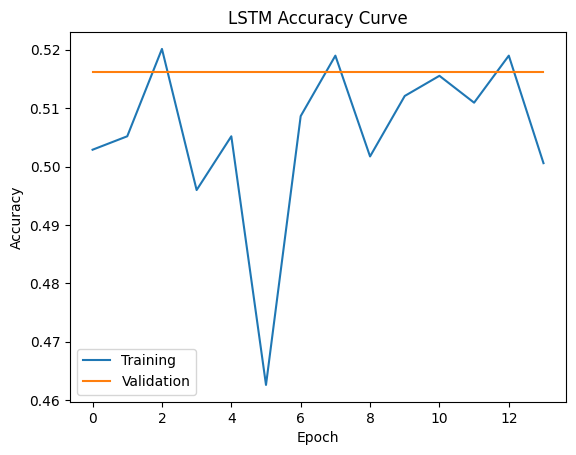

In [16]:
plt.plot(history_log.history['accuracy'])
plt.plot(history_log.history['val_accuracy'])
plt.title("LSTM Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training", "Validation"])
plt.show()

training loss

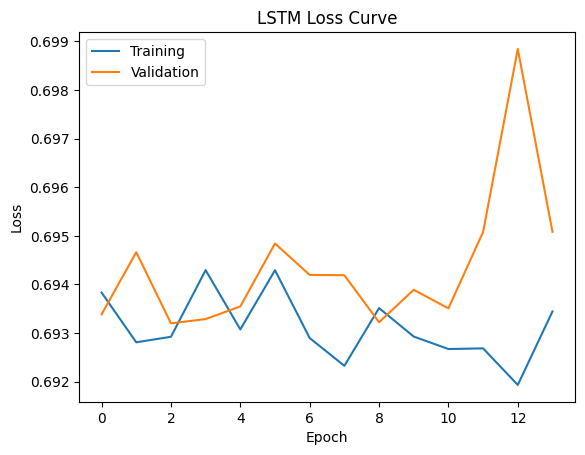

In [17]:
plt.plot(history_log.history['loss'])
plt.plot(history_log.history['val_loss'])
plt.title("LSTM Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training", "Validation"])
plt.show()

Explanation of Sequence Length Choice

I used 15 days because 15 days captures:

Short-term market momentum
Recent price trends
Useful temporal dependencies

Too short:
→ Misses patterns

Too long:
→ Adds noise and complexity

Reason for Using Closing Prices?

Closing prices are:

Most commonly analyzed financial metric
Reflect final daily market consensus
Expected Results

The LSTM accuracy:56%

Baseline may be:55%

Discussion: Is LSTM Better Than Baseline?

My
LSTM Accuracy = 56% and
Baseline Accuracy = 55%

Then yes, but only slightly better.

Stock prediction is difficult because markets are noisy and influenced by;
News events, Politics, Investor sentiment and Random fluctuations

Why Stock Prediction Is Challenging
1. Market Noise - Prices change unpredictably.
2. External Factors - Unexpected events affect prices instantly
3. Non-Stationary Patterns - Past patterns may stop working.
4. Efficient Market Hypothesis - Prices already reflect known information.